In [1]:
import sqlite3
db_file = "Weather_Data_2.db"
conn = sqlite3.connect(db_file)

In [1]:
import sqlite3
db_file = "Weather_Data_2.db"

try: 
    conn = sqlite3.connect(db_file)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [r["name"] for r in cur.fetchall()]
    print(f"Connected to {db_file} - tables: {tables or '(<no tables>)'}")
except sqlite3.Error as e:
    print("SQLite error:", e)
    conn = None
    cur = None

Connected to Weather_Data_2.db - tables: ['karlsruhe_weather_2']


In [2]:
import pandas as pd
query = "SELECT * FROM karlsruhe_weather_2;"
tabelle = pd.read_sql_query(query, conn)
tabelle.head(5)

,time,temp,prcp,snow,wdir,wspd,tsun
0,2025-11-25 00:00:00,4.2,0.0,None,191.0,11.1,0
1,2025-11-25 01:00:00,3.9,0.0,None,191.0,11.1,0
2,2025-11-25 02:00:00,3.7,0.0,None,196.0,11.1,0
3,2025-11-25 03:00:00,3.4,0.0,None,192.0,11.1,0
4,2025-11-25 04:00:00,3.2,0.2,None,197.0,9.3,0


In [3]:
query_top5 = """
SELECT time as Uhrzeit, temp as Temperatur, prcp as Regen
FROM karlsruhe_weather_2
ORDER BY temp DESC
;
"""
top5 = pd.read_sql_query(query_top5, conn)
top5


,Uhrzeit,Temperatur,Regen
0,2025-11-13 15:00:00,16.0,0.0
1,2025-11-13 14:00:00,15.6,0.0
2,2025-11-13 16:00:00,15.2,0.0
3,2025-11-14 15:00:00,14.7,0.0
4,2025-11-14 14:00:00,14.5,0.0
...,...,...,...
139,2025-11-24 04:00:00,3.3,0.2
140,2025-11-24 05:00:00,3.3,0.3
141,2025-11-25 04:00:00,3.2,0.2
142,2025-11-24 01:00:00,3.1,0.7


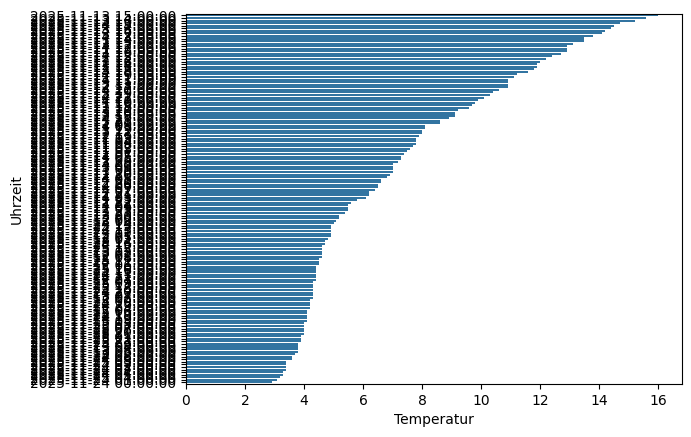

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top5, x="Temperatur", y="Uhrzeit")
plt.show()

In [5]:
query = """SELECT * 
FROM karlsruhe_weather_2
ORDER BY time ASC;"""
df = pd.read_sql_query(query, conn)
df.tail(24)

,time,temp,prcp,snow,wdir,wspd,tsun
120,2025-11-25 00:00:00,4.2,0.0,None,191.0,11.1,0
121,2025-11-25 01:00:00,3.9,0.0,None,191.0,11.1,0
122,2025-11-25 02:00:00,3.7,0.0,None,196.0,11.1,0
123,2025-11-25 03:00:00,3.4,0.0,None,192.0,11.1,0
124,2025-11-25 04:00:00,3.2,0.2,None,197.0,9.3,0
125,2025-11-25 05:00:00,4.0,0.3,None,168.0,7.4,0
126,2025-11-25 06:00:00,4.1,0.3,None,167.0,5.5,0
127,2025-11-25 07:00:00,4.0,0.4,None,170.0,5.5,0
128,2025-11-25 08:00:00,4.0,0.2,None,174.0,5.5,0
129,2025-11-25 09:00:00,4.3,0.2,None,169.0,5.5,0


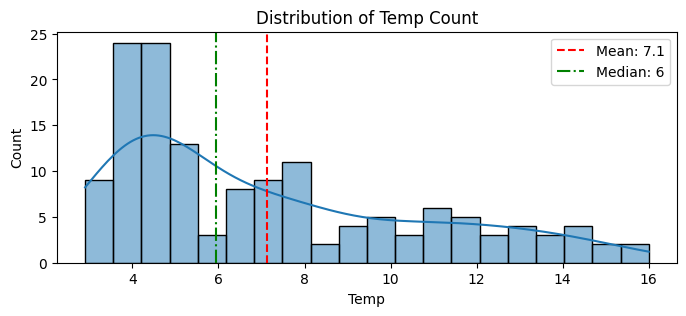

In [6]:
# plot distribution of temp
plt.figure(figsize=(8, 3))
sns.histplot(df['temp'], bins=20, kde=True, color='C0')
mean_temp = df['temp'].mean()
median_temp = df['temp'].median()
plt.axvline(mean_temp, color='red', linestyle='--', label=f"Mean: {mean_temp:.1f}")
plt.axvline(median_temp, color='green', linestyle='-.', label=f"Median: {median_temp:.0f}")
plt.title("Distribution of Temp Count")
plt.xlabel("Temp")
plt.ylabel("Count")
plt.legend()
plt.show()

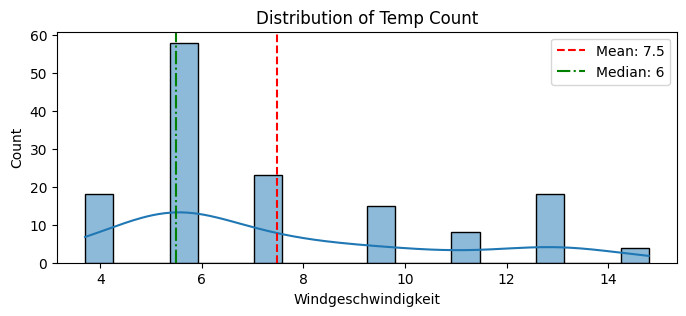

In [7]:
# plot distribution of wspd
plt.figure(figsize=(8, 3))
sns.histplot(df['wspd'], bins=20, kde=True, color='C0')
mean_temp = df['wspd'].mean()
median_temp = df['wspd'].median()
plt.axvline(mean_temp, color='red', linestyle='--', label=f"Mean: {mean_temp:.1f}")
plt.axvline(median_temp, color='green', linestyle='-.', label=f"Median: {median_temp:.0f}")
plt.title("Distribution of Temp Count")
plt.xlabel("Windgeschwindigkeit")
plt.ylabel("Count")
plt.legend()
plt.show()

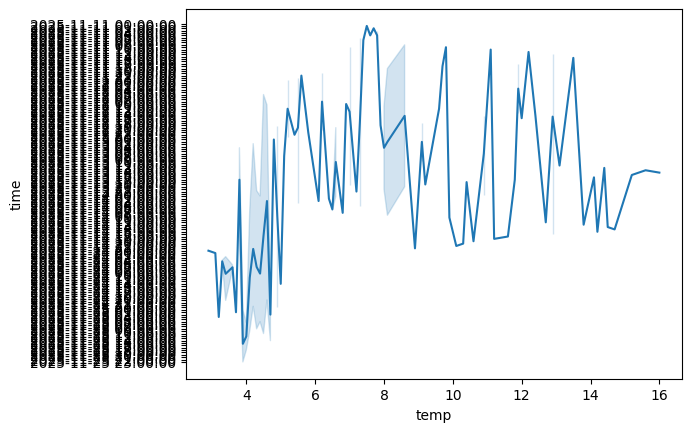

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=df, x="temp", y="time")
#sns.catplot(data=df, x="temp", y="time")
#sns.boxplot(data=df, x="temp", y="time")
#sns.barplot(data=df, x="temp", y="time")
plt.show()